<a href="https://colab.research.google.com/github/Alchwalch/Deep-Learning-Study/blob/main/NLP/Word2vec.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import matplotlib.pyplot as plt
import collections
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import Subset,DataLoader,random_split,Dataset
import torch.nn.functional as F
from tqdm.notebook import tqdm
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [ ]:
from google.colab import drive
import os
drive.mount('/content/drive')

# Numpy 구현

In [ ]:
%%script echo skip

class Embedding:
  def __init__(self,W):
    self.params=[W]
    self.grads=[np.zeros_like(W)]
    self.idx=None

  def forward(self,idx):
    W, =self.params
    self.idx=idx
    out=W[idx]
    return out

  def backward(self, dout):
    dW, = self.grads
    dW[...] = 0
    np.add.at(dW, self.idx, dout)
    return None

In [ ]:
%%script echo skip

class EmbeddingDot:
    def __init__(self, W):
        self.embed = Embedding(W)
        self.params = self.embed.params
        self.grads = self.embed.grads
        self.cache = None

    def forward(self, h, idx):
        target_W = self.embed.forward(idx)
        out = np.sum(target_W * h, axis=1)

        self.cache = (h, target_W)
        return out

    def backward(self, dout):
        h, target_W = self.cache
        dout = dout.reshape(dout.shape[0], 1)

        dtarget_W = dout * h
        self.embed.backward(dtarget_W)
        dh = dout * target_W
        return dh

In [ ]:
%%script echo skip

def cross_entropy_error(y, t):
    if y.ndim == 1:
        t = t.reshape(1, t.size)
        y = y.reshape(1, y.size)

    # 정답 데이터가 원핫 벡터일 경우 정답 레이블 인덱스로 변환
    if t.size == y.size:
        t = t.argmax(axis=1)

    batch_size = y.shape[0]

    return -np.sum(np.log(y[np.arange(batch_size), t] + 1e-7)) / batch_size

In [ ]:
%%script echo skip

class SigmoidWithLoss:
    def __init__(self):
        self.params, self.grads = [], []
        self.loss = None
        self.y = None
        self.t = None

    def forward(self, x, t):
        self.t = t
        self.y = 1 / (1 + np.exp(-x))

        self.loss = cross_entropy_error(np.c_[1 - self.y, self.y], self.t)

        return self.loss

    def backward(self, dout=1):
        batch_size = self.t.shape[0]

        dx = (self.y - self.t) * dout / batch_size
        return dx

In [ ]:
%%script echo skip

class UnigramSampler:
    def __init__(self, corpus, power, sample_size):
        self.sample_size = sample_size
        self.vocab_size = None
        self.word_p = None

        counts = collections.Counter()
        for word_id in corpus:
            counts[word_id] += 1

        vocab_size = len(counts)
        self.vocab_size = vocab_size

        self.word_p = np.zeros(vocab_size)
        for i in range(vocab_size):
            self.word_p[i] = counts[i]

        self.word_p = np.power(self.word_p, power)
        self.word_p /= np.sum(self.word_p)

    def get_negative_sample(self, target):
        batch_size = target.shape[0]

        negative_sample = np.zeros((batch_size, self.sample_size), dtype=np.int32)

        for i in range(batch_size):
            p = self.word_p.copy()
            target_idx = target[i]
            p[target_idx] = 0
            p /= p.sum()
            negative_sample[i, :] = np.random.choice(self.vocab_size, size=self.sample_size, replace=False, p=p)

        return negative_sample

In [ ]:
%%script echo skip

class NegativeSamplingLoss:
    def __init__(self, W, corpus, power=0.75, sample_size=5):
        self.sample_size = sample_size
        self.sampler = UnigramSampler(corpus, power, sample_size)
        self.loss_layers = [SigmoidWithLoss() for _ in range(sample_size + 1)]
        self.embed_dot_layers = [EmbeddingDot(W) for _ in range(sample_size + 1)]

        self.params, self.grads = [], []
        for layer in self.embed_dot_layers:
            self.params += layer.params
            self.grads += layer.grads

    def forward(self, h, target):
        batch_size = target.shape[0]
        negative_sample = self.sampler.get_negative_sample(target)

        score = self.embed_dot_layers[0].forward(h, target)
        correct_label = np.ones(batch_size, dtype=np.int32)
        loss = self.loss_layers[0].forward(score, correct_label)

        negative_label = np.zeros(batch_size, dtype=np.int32)
        for i in range(self.sample_size):
            negative_target = negative_sample[:, i]
            score = self.embed_dot_layers[1 + i].forward(h, negative_target)
            loss += self.loss_layers[1 + i].forward(score, negative_label)

        return loss

    def backward(self, dout=1):
        dh = 0
        for l0, l1 in zip(self.loss_layers, self.embed_dot_layers):
            dscore = l0.backward(dout)
            dh += l1.backward(dscore)

        return dh

In [ ]:
%%script echo skip

class CBOW:
    def __init__(self, vocab_size, hidden_size, window_size, corpus):
        V, H = vocab_size, hidden_size

        W_in = 0.01 * np.random.randn(V, H).astype('f')
        W_out = 0.01 * np.random.randn(V, H).astype('f')

        self.in_layers = []
        for i in range(2 * window_size):
            layer = Embedding(W_in)
            self.in_layers.append(layer)
        self.ns_loss = NegativeSamplingLoss(W_out, corpus, power=0.75, sample_size=5)

        layers = self.in_layers + [self.ns_loss]
        self.params, self.grads = [], []
        for layer in layers:
            self.params += layer.params
            self.grads += layer.grads

        self.word_vecs = W_in

    def forward(self, contexts, target):
        h = 0
        for i, layer in enumerate(self.in_layers):
            h += layer.forward(contexts[:, i])
        h *= 1 / len(self.in_layers)
        loss = self.ns_loss.forward(h, target)
        return loss

    def backward(self, dout=1):
        dout = self.ns_loss.backward(dout)
        dout *= 1 / len(self.in_layers)
        for layer in self.in_layers:
            layer.backward(dout)
        return None

In [ ]:
%%script echo skip

class SkipGram:
    def __init__(self, vocab_size, hidden_size, window_size, corpus):
        V, H = vocab_size, hidden_size

        W_in = 0.01 * np.random.randn(V, H).astype('f')
        W_out = 0.01 * np.random.randn(V, H).astype('f')

        self.in_layer = Embedding(W_in)
        self.loss_layers=[]
        for i in range(2 * window_size):
          layer = NegativeSamplingLoss(W_out, corpus, power=0.75, sample_size=5)
          self.loss_layers.append(layer)

        layers = [self.in_layer] + self.loss_layers
        self.params, self.grads = [], []
        for layer in layers:
            self.params += layer.params
            self.grads += layer.grads

        self.word_vecs = W_in

    def forward(self, contexts, target):
        h = self.in_layer.forward(target)

        loss=0
        for i, layer in enumerate(self.loss_layers):
            loss += layer.forward(h,contexts[:, i])
        return loss

    def backward(self, dout=1):
        dh=0
        for layer in self.loss_layers:
            dh+=layer.backward(dout)
        self.in_layer.backward(dh)
        return None

# Pytorch

In [ ]:
class UnigramSampler(nn.Module):
    def __init__(self, corpus, vocab_size, power, sample_size, device='cpu'):
        super().__init__()
        self.sample_size = sample_size
        self.vocab_size = vocab_size

        corpus_t = torch.tensor(corpus, dtype=torch.long)
        word_p = torch.bincount(corpus_t, minlength=vocab_size).float()

        word_p = torch.pow(word_p, power)
        word_p /= torch.sum(word_p)
        self.register_buffer('word_p', word_p)

    """
    def get_negative_sample(self, target):
        batch_size = target.shape[0]
        p = self.word_p.unsqueeze(0).expand(batch_size, -1).clone()  # (B, V)
        p.scatter_(1, target.unsqueeze(1), 0)                         # 각 행에서 target 위치만 0으로
        p = p / p.sum(dim=1, keepdim=True)
        return torch.multinomial(p, self.sample_size, replacement=False)
        """

    def get_negative_sample(self, target):
        batch_size = target.shape[0]
        # 어차피 target 뽑힐 확률 1/200000
        neg = torch.multinomial(
            self.word_p, batch_size * self.sample_size, replacement=True
        )
        return neg.view(batch_size, self.sample_size)

In [ ]:
class NegativeSamplingLoss(nn.Module):
    def __init__(self, out_embed, corpus, vocab_size, power=0.75, sample_size=5,device='cpu'):
        super().__init__()
        self.sampler = UnigramSampler(corpus, vocab_size, power, sample_size, device)
        self.out_embed = out_embed


    def forward(self, h, target):
        batch_size = target.shape[0]
        negative_sample = self.sampler.get_negative_sample(target)

        pos_score = (self.out_embed(target) * h).sum(-1)        # (B,)
        neg_score = torch.bmm(self.out_embed(negative_sample), h.unsqueeze(2)).squeeze(2)  # (B, K)

        loss = F.logsigmoid(pos_score).mean() + F.logsigmoid(-neg_score).sum(-1).mean()

        return -loss

In [ ]:
class CBOW(nn.Module):
    def __init__(self, vocab_size, embed_dim, corpus, power=0.75, sample_size=5,device='cpu'):
        super().__init__()
        self.in_embed = nn.Embedding(vocab_size, embed_dim)
        self.out_embed = nn.Embedding(vocab_size, embed_dim)

        with torch.no_grad():
            self.in_embed.weight.copy_(0.01 * torch.randn(vocab_size, embed_dim))
            self.out_embed.weight.copy_(0.01 * torch.randn(vocab_size, embed_dim))

        self.neg=NegativeSamplingLoss(self.out_embed, corpus, vocab_size, power, sample_size,device)

    def forward(self, context, target):
        # context: (B, C), target: (B,)
        h = self.in_embed(context).mean(dim=1)                      # (B, D)
        loss = self.neg(h, target)
        return loss

In [ ]:
class SkipGram(nn.Module):
  def __init__(self, vocab_size, embed_dim, corpus, power=0.75, sample_size=5,device='cpu'):
    super().__init__()
    self.in_embed = nn.Embedding(vocab_size, embed_dim)
    self.out_embed = nn.Embedding(vocab_size, embed_dim)

    with torch.no_grad():
      self.in_embed.weight.copy_(0.01 * torch.randn(vocab_size, embed_dim))
      self.out_embed.weight.copy_(0.01 * torch.randn(vocab_size, embed_dim))

    self.neg=NegativeSamplingLoss(self.out_embed, corpus, vocab_size, power, sample_size,device)

  def forward(self, context, target):
    B, C = context.shape

    h = self.in_embed(target)                           # (B, D)
    h_expand = h.unsqueeze(1).expand(-1, C, -1)         # (B, C, D)
    h_flat = h_expand.reshape(B * C, -1)                # (B*C, D)
    context_flat = context.reshape(B * C)               # (B*C,)

    loss = self.neg(h_flat, context_flat)               # 기존 NegativeSamplingLoss 그대로 재사용
    return loss

# Data

In [ ]:
def negative_subsampling(corpus, vocab_size, threshold=1e-5, device='cpu'):

    corpus_t = torch.tensor(corpus, dtype=torch.long)
    word_p = torch.bincount(corpus_t, minlength=vocab_size).float()

    word_p /= torch.sum(word_p)

    discard_prob = 1 - torch.sqrt(threshold / word_p)
    discard_prob = torch.clamp(discard_prob, min=0.0)   # 음수 방지 (희귀 단어는 버릴 확률 0)

    return discard_prob

In [ ]:
def subsample_corpus(corpus, discard_prob):
    corpus_t = torch.tensor(corpus, dtype=torch.long)
    p_discard = discard_prob[corpus_t]      # 각 위치 단어의 버릴 확률
    keep_mask = torch.rand(len(corpus)) >= p_discard
    return corpus_t[keep_mask].tolist()

In [ ]:
import urllib.request, zipfile, os

class Text8Corpus:

  def __init__(self,subsample_threshold=1e-5):
    if not os.path.exists('text8'):
        urllib.request.urlretrieve('http://mattmahoney.net/dc/text8.zip', 'text8.zip')
        with zipfile.ZipFile('text8.zip') as z:
            z.extractall()

    with open('text8', 'r') as f:
        raw_text = f.read()

    tokenized_text = raw_text.split()

    vocab = list(set(tokenized_text))
    self.word_to_id = {word: i for i, word in enumerate(vocab)}
    self.id_to_word = {i: word for i, word in enumerate(vocab)}

    self.corpus = [self.word_to_id[word] for word in tokenized_text]
    self.vocab_size = len(vocab)

    self.discard_prob = negative_subsampling(self.corpus, self.vocab_size, threshold=subsample_threshold)

  def get_data(self, window_size):
    corpus_subsampled = subsample_corpus(self.corpus, self.discard_prob)
    data = []
    for i in range(window_size, len(corpus_subsampled) - window_size):
        context_ids = [corpus_subsampled[i + j] for j in range(-window_size, window_size + 1) if j != 0]
        target_id = corpus_subsampled[i]
        data.append((context_ids, target_id))

    return data,corpus_subsampled

In [ ]:
class Word2VecDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        context_ids, target_id = self.data[idx]
        return torch.tensor(context_ids, dtype=torch.long), torch.tensor(target_id, dtype=torch.long)

# Accuracy

In [ ]:
def get_nearest_neighbors(word, model, word_to_id, id_to_word, top_k=5):
    embeddings = model.in_embed.weight.detach()   # (V, D)
    embeddings = F.normalize(embeddings, dim=1)    # 코사인 유사도를 위해 정규화

    word_id = word_to_id[word]
    word_vec = embeddings[word_id]

    sims = embeddings @ word_vec   # (V,) 코사인 유사도
    top_ids = sims.argsort(descending=True)[1:top_k+1]   # 자기 자신 제외

    return [(id_to_word[i.item()], sims[i].item()) for i in top_ids]

In [ ]:
def word_analogy(word_a, word_b, word_c, model, word_to_id, id_to_word, word_freq, min_count=100, top_k=5):
    embeddings = model.in_embed.weight.detach()
    embeddings = F.normalize(embeddings, dim=1)

    for w in (word_a, word_b, word_c):
        if w not in word_to_id:
            raise ValueError(f"'{w}' is not in vocabulary")

    vec_a = embeddings[word_to_id[word_a]]
    vec_b = embeddings[word_to_id[word_b]]
    vec_c = embeddings[word_to_id[word_c]]

    query_vec = F.normalize(vec_a - vec_b + vec_c, dim=0)
    sims = embeddings @ query_vec

    exclude_ids = {word_to_id[word_a], word_to_id[word_b], word_to_id[word_c]}
    for idx in exclude_ids:
        sims[idx] = -float('inf')

    # 등장 빈도가 min_count 미만인 단어는 후보에서 제외
    low_freq_mask = word_freq < min_count
    sims[low_freq_mask] = -float('inf')

    # Explicitly ensure top_k is an integer for slicing
    top_k_int = int(top_k)
    top_ids = sims.argsort(descending=True)[:top_k_int]
    return [(id_to_word[i.item()], sims[i].item()) for i in top_ids]

# Training

In [ ]:
#%%script echo skip

epochs=20
start_epoch=0
learning_rate=1e-3
batch_size=512
patience = 5
device='cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
corpus_obj = Text8Corpus(subsample_threshold=1e-5)

model=SkipGram(
    vocab_size=corpus_obj.vocab_size,
    embed_dim=100,
    corpus=corpus_obj.corpus,
    device=device
)
model.to(device)
optimizer=optim.Adam(model.parameters(),lr=learning_rate)
scheduler=optim.lr_scheduler.ReduceLROnPlateau(optimizer,mode='min',factor=0.5,patience=3)

In [ ]:
best_loss=float('inf')
no_improve=0
train_loss_list=[]

In [ ]:
path = f'/content/drive/MyDrive/SkipGram.pth'
if os.path.exists(path):
    checkpoint = torch.load(path)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    train_loss_list = checkpoint['train_loss_list']
    best_loss = checkpoint['best_loss']
    start_epoch = checkpoint['epoch']+1

In [ ]:
print(corpus_obj.vocab_size)

In [ ]:
for epoch in tqdm(range(start_epoch, epochs), desc="Epoch"):

    train_loss = 0.0
    data,_=corpus_obj.get_data(window_size=5)
    train_dataset = Word2VecDataset(data)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    model.train()
    for context, target in tqdm(train_loader, desc="Iteration", leave=False):
        context, target = context.to(device), target.to(device)
        optimizer.zero_grad()
        loss = model(context,target)
        loss.backward()
        train_loss += loss.item()
        optimizer.step()

    train_loss /= len(train_loader)
    train_loss_list.append(train_loss)

    scheduler.step(train_loss)

    if train_loss < best_loss:
        best_loss = train_loss
        no_improve = 0
        torch.save({
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_loss': best_loss,
            'train_loss_list': train_loss_list,
            'epoch': epoch
        }, f'/content/drive/MyDrive/SkipGram.pth')
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"Early Stopping at Epoch {epoch+1}")
            break

    print(f'Epoch {epoch+1} | Loss: {train_loss_list[-1]:.4f}')

In [ ]:
plt.plot(train_loss_list, label='train')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

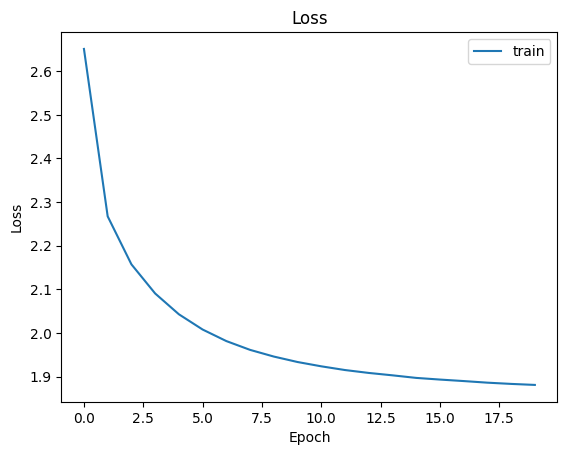

In [ ]:
querys=['king','you','october','year','car','tokyo','mother','off','new','the']

for query in querys:
  print()
  print(query)
  neighbors=get_nearest_neighbors(query, model, corpus_obj.word_to_id, corpus_obj.id_to_word)
  for neighbor in neighbors:
    print(neighbor)





In [ ]:
word_freq = torch.bincount(torch.tensor(corpus_obj.corpus), minlength=corpus_obj.vocab_size)
analogy_querys=[['king', 'man', 'woman'],
        ['paris', 'france', 'italy'],
        ['tokyo', 'japan', 'korea'],
        ['seoul', 'korea', 'japan'],
        ['walked', 'walk', 'run']]

for query in analogy_querys:
  print()
  print(query[0]+' - '+query[1]+' + '+query[2])
  analogies=word_analogy(query[0],query[1],query[2], model, corpus_obj.word_to_id, corpus_obj.id_to_word, word_freq)
  for analogy in analogies:
    print(analogy)



In [ ]:
# seoul이 실제로 몇 위인지, 코사인 유사도가 얼마인지 확인
embeddings = F.normalize(model.in_embed.weight.detach(), dim=1)
query = F.normalize(embeddings[corpus_obj.word_to_id['tokyo']] - embeddings[corpus_obj.word_to_id['japan']] + embeddings[corpus_obj.word_to_id['korea']], dim=0)
sims = embeddings @ query
seoul_rank = (sims.argsort(descending=True) == corpus_obj.word_to_id['seoul']).nonzero().item()
print(seoul_rank, sims[corpus_obj.word_to_id['seoul']].item())